# Compare QM9 with MLPR Predictions

This notebook compares a random selection of 10,000 molecules from the QM9 dataset with the predicted HOMO-LUMO gap values from a trained MLP Regressor model.

The steps are:
1. Load the QM9 dataset.
2. Select a random sample of 10,000 molecules.
3. Calculate molecular descriptors for the sample.
4. Load the pre-trained MLPR model.
5. Predict the HOMO-LUMO gap for the sample.
6. Create a scatter plot to compare the QM9 `gap` values with the predicted values.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from joblib import load
from matplotlib.colors import LogNorm
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors
from sklearn.preprocessing import MinMaxScaler, StandardScaler


In [2]:
def canonicalize_smiles(smiles: str) -> str | None:
    """
    Converts a SMILES string to its canonical form using RDKit.

    Args:
        smiles: The input SMILES string.

    Returns:
        The canonical SMILES string, or None if the input is invalid.
    """
    # Add this check at the beginning to handle None inputs gracefully
    if smiles is None:
        return None

    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        return Chem.MolToSmiles(mol)
    except Exception:
        return None


def is_canonical(smiles: str) -> bool:
    """
    Checks if a SMILES string is canonical using RDKit.

    Args:
        smiles: The input SMILES string to check.

    Returns:
        True if the SMILES is canonical, False otherwise.
        Returns False if the SMILES is invalid.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        # The input SMILES is invalid
        return False

    # Generate the canonical SMILES from the molecule object
    canonical_smiles = Chem.MolToSmiles(mol)

    # Compare the input with the canonical version
    return smiles == canonical_smiles


def remove_stereochemistry(smiles: str) -> str | None:
    """
    Parses a SMILES string and returns its canonical, achiral form.
    Includes error handling to return None if any step fails.
    """
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        # This single call generates the canonical SMILES of the achiral graph
        return Chem.MolToSmiles(mol, isomericSmiles=False)
    except Exception:
        return None

## 1. Load QM9 Dataset

In [3]:
data_dir = Path("../data/external/QM9/raw")
csv_path = data_dir / "gdb9.sdf.csv"
df_qm9 = pd.read_csv(csv_path)
print(f"QM9 DataFrame loaded from CSV: {csv_path}")
df_qm9

QM9 DataFrame loaded from CSV: ../data/external/QM9/raw/gdb9.sdf.csv


,mol_id,A,B,C,mu,alpha,homo,lumo,gap,r2,zpve,u0,u298,h298,g298,cv,u0_atom,u298_atom,h298_atom,g298_atom
0,gdb_1,157.71180,157.709970,157.706990,0.0000,13.21,-0.3877,0.1171,0.5048,35.3641,0.044749,-40.478930,-40.476062,-40.475117,-40.498597,6.469,-395.999595,-398.643290,-401.014647,-372.471772
1,gdb_2,293.60975,293.541110,191.393970,1.6256,9.46,-0.2570,0.0829,0.3399,26.1563,0.034358,-56.525887,-56.523026,-56.522082,-56.544961,6.316,-276.861363,-278.620271,-280.399259,-259.338802
2,gdb_3,799.58812,437.903860,282.945450,1.8511,6.31,-0.2928,0.0687,0.3615,19.0002,0.021375,-76.404702,-76.401867,-76.400922,-76.422349,6.002,-213.087624,-213.974294,-215.159658,-201.407171
3,gdb_4,0.00000,35.610036,35.610036,0.0000,16.28,-0.2845,0.0506,0.3351,59.5248,0.026841,-77.308427,-77.305527,-77.304583,-77.327429,8.574,-385.501997,-387.237686,-389.016047,-365.800724
4,gdb_5,0.00000,44.593883,44.593883,2.8937,12.99,-0.3604,0.0191,0.3796,48.7476,0.016601,-93.411888,-93.409370,-93.408425,-93.431246,6.278,-301.820534,-302.906752,-304.091489,-288.720028
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133880,gdb_133881,3.59483,2.198990,1.904230,1.6637,69.37,-0.2254,0.0588,0.2842,760.7472,0.127406,-400.633868,-400.628599,-400.627654,-400.663098,23.658,-1603.983913,-1614.898804,-1623.788097,-1492.819438
133881,gdb_133882,3.65648,2.142370,1.904390,1.2976,69.52,-0.2393,0.0608,0.3002,762.6354,0.127495,-400.629713,-400.624444,-400.623500,-400.658942,23.697,-1601.376613,-1612.291504,-1621.181424,-1490.211511
133882,gdb_133883,3.67118,2.143140,1.895010,1.2480,73.60,-0.2233,0.0720,0.2953,780.3553,0.140458,-380.753918,-380.748619,-380.747675,-380.783148,23.972,-1667.045429,-1678.830048,-1688.312964,-1549.143391
133883,gdb_133884,3.52845,2.151310,1.865820,1.9576,77.40,-0.2122,0.0881,0.3003,803.1904,0.152222,-364.720374,-364.714974,-364.714030,-364.749650,24.796,-1794.600439,-1807.210860,-1817.286772,-1670.349892


In [4]:
hartree_to_ev = 27.2114

df_qm9["homo_eV"] = df_qm9["homo"] * hartree_to_ev
df_qm9["lumo_eV"] = df_qm9["lumo"] * hartree_to_ev
df_qm9["gap_eV"] = df_qm9["gap"] * hartree_to_ev

print("Converted 'homo', 'lumo', and 'gap' to eV.")
print(df_qm9[["homo", "homo_eV", "lumo", "lumo_eV", "gap", "gap_eV"]].head())

Converted 'homo', 'lumo', and 'gap' to eV.
     homo    homo_eV    lumo   lumo_eV     gap     gap_eV
0 -0.3877 -10.549860  0.1171  3.186455  0.5048  13.736315
1 -0.2570  -6.993330  0.0829  2.255825  0.3399   9.249155
2 -0.2928  -7.967498  0.0687  1.869423  0.3615   9.836921
3 -0.2845  -7.741643  0.0506  1.376897  0.3351   9.118540
4 -0.3604  -9.806989  0.0191  0.519738  0.3796  10.329447


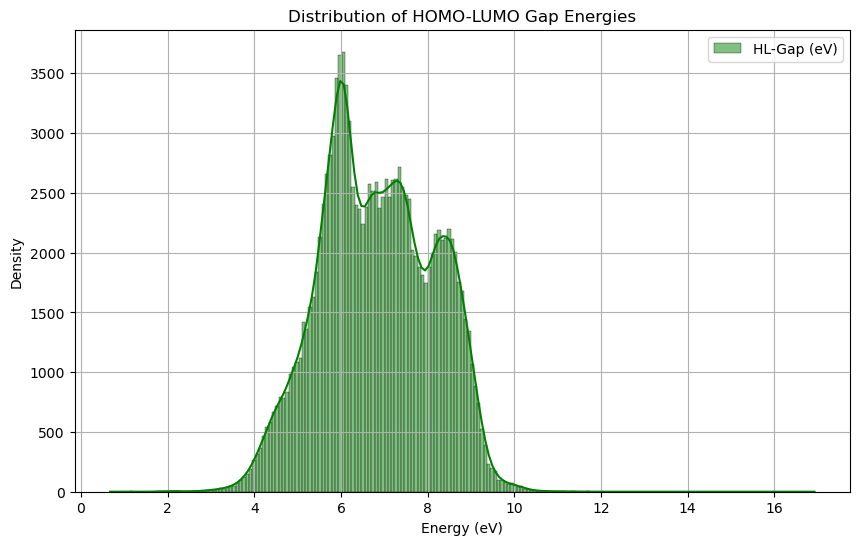

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(df_qm9["gap_eV"], color="green", label="HL-Gap (eV)", kde=True)
plt.title("Distribution of HOMO-LUMO Gap Energies")
plt.xlabel("Energy (eV)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
sdf_path = data_dir / "gdb9.sdf"

with open(sdf_path, "r") as f:
    sdf_content = f.read()

sdf_entries = sdf_content.strip().split("$$$$\n")

# Remove the last empty entry if it exists due to trailing '$$$$'
if sdf_entries and not sdf_entries[-1].strip():
    sdf_entries.pop()

df_qm9["sdf_text"] = sdf_entries

print(f"Loaded {len(sdf_entries)} SDF entries from {sdf_path} and added to df_qm9.")
df_qm9

Loaded 133885 SDF entries from ../data/external/QM9/raw/gdb9.sdf and added to df_qm9.


,mol_id,A,B,C,mu,alpha,homo,lumo,gap,r2,...,g298,cv,u0_atom,u298_atom,h298_atom,g298_atom,homo_eV,lumo_eV,gap_eV,sdf_text
0,gdb_1,157.71180,157.709970,157.706990,0.0000,13.21,-0.3877,0.1171,0.5048,35.3641,...,-40.498597,6.469,-395.999595,-398.643290,-401.014647,-372.471772,-10.549860,3.186455,13.736315,gdb_1\n -OEChem-03231823243D\n\n 5 4 0 ...
1,gdb_2,293.60975,293.541110,191.393970,1.6256,9.46,-0.2570,0.0829,0.3399,26.1563,...,-56.544961,6.316,-276.861363,-278.620271,-280.399259,-259.338802,-6.993330,2.255825,9.249155,gdb_2\n -OEChem-03231823233D\n\n 4 3 0 ...
2,gdb_3,799.58812,437.903860,282.945450,1.8511,6.31,-0.2928,0.0687,0.3615,19.0002,...,-76.422349,6.002,-213.087624,-213.974294,-215.159658,-201.407171,-7.967498,1.869423,9.836921,gdb_3\n -OEChem-03231823243D\n\n 3 2 0 ...
3,gdb_4,0.00000,35.610036,35.610036,0.0000,16.28,-0.2845,0.0506,0.3351,59.5248,...,-77.327429,8.574,-385.501997,-387.237686,-389.016047,-365.800724,-7.741643,1.376897,9.118540,gdb_4\n -OEChem-03231823253D\n\n 4 3 0 ...
4,gdb_5,0.00000,44.593883,44.593883,2.8937,12.99,-0.3604,0.0191,0.3796,48.7476,...,-93.431246,6.278,-301.820534,-302.906752,-304.091489,-288.720028,-9.806989,0.519738,10.329447,gdb_5\n -OEChem-03231823253D\n\n 3 2 0 ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133880,gdb_133881,3.59483,2.198990,1.904230,1.6637,69.37,-0.2254,0.0588,0.2842,760.7472,...,-400.663098,23.658,-1603.983913,-1614.898804,-1623.788097,-1492.819438,-6.133450,1.600030,7.733480,gdb_133881\n -OEChem-03231823243D\n\n 16 21 ...
133881,gdb_133882,3.65648,2.142370,1.904390,1.2976,69.52,-0.2393,0.0608,0.3002,762.6354,...,-400.658942,23.697,-1601.376613,-1612.291504,-1621.181424,-1490.211511,-6.511688,1.654453,8.168862,gdb_133882\n -OEChem-03231823253D\n\n 16 21 ...
133882,gdb_133883,3.67118,2.143140,1.895010,1.2480,73.60,-0.2233,0.0720,0.2953,780.3553,...,-380.783148,23.972,-1667.045429,-1678.830048,-1688.312964,-1549.143391,-6.076306,1.959221,8.035526,gdb_133883\n -OEChem-03231823253D\n\n 17 21 ...
133883,gdb_133884,3.52845,2.151310,1.865820,1.9576,77.40,-0.2122,0.0881,0.3003,803.1904,...,-364.749650,24.796,-1794.600439,-1807.210860,-1817.286772,-1670.349892,-5.774259,2.397324,8.171583,gdb_133884\n -OEChem-03231823253D\n\n 18 22 ...


In [7]:
def sdf_to_mol_and_smiles(sdf_text):
    mol = Chem.MolFromMolBlock(sdf_text)
    if mol is not None:
        return mol, Chem.MolToSmiles(mol)
    return None, None


df_qm9[["mol", "smiles"]] = df_qm9["sdf_text"].apply(
    lambda x: pd.Series(sdf_to_mol_and_smiles(x))
)
df_qm9["achiralSmiles"] = df_qm9["smiles"].apply(remove_stereochemistry)
df_qm9["canonicalSmiles"] = df_qm9["achiralSmiles"].apply(canonicalize_smiles)
print("Added 'mol' and 'smiles' columns to df_qm9.")
df_qm9

[07:25:54] Warning: molecule is tagged as 3D, but all Z coords are zero
[07:25:54] Explicit valence for atom # 1 C, 5, is greater than permitted
[07:25:54] Warning: molecule is tagged as 3D, but all Z coords are zero
[07:25:54] Explicit valence for atom # 1 C, 5, is greater than permitted
[07:25:54] Explicit valence for atom # 4 C, 5, is greater than permitted
[07:25:54] Explicit valence for atom # 2 C, 5, is greater than permitted
[07:25:54] Explicit valence for atom # 2 C, 5, is greater than permitted
[07:25:54] Explicit valence for atom # 2 C, 5, is greater than permitted
[07:25:54] Explicit valence for atom # 2 C, 5, is greater than permitted
[07:25:54] Explicit valence for atom # 2 C, 5, is greater than permitted
[07:25:54] Explicit valence for atom # 1 C, 5, is greater than permitted
[07:25:54] Explicit valence for atom # 1 C, 5, is greater than permitted
[07:25:54] Explicit valence for atom # 4 C, 5, is greater than permitted
[07:25:54] Explicit valence for atom # 2 C, 5, is gre

Added 'mol' and 'smiles' columns to df_qm9.


,mol_id,A,B,C,mu,alpha,homo,lumo,gap,r2,...,h298_atom,g298_atom,homo_eV,lumo_eV,gap_eV,sdf_text,mol,smiles,achiralSmiles,canonicalSmiles
0,gdb_1,157.71180,157.709970,157.706990,0.0000,13.21,-0.3877,0.1171,0.5048,35.3641,...,-401.014647,-372.471772,-10.549860,3.186455,13.736315,gdb_1\n -OEChem-03231823243D\n\n 5 4 0 ...,<rdkit.Chem.rdchem.Mol object at 0x7a3c9b895c40>,C,C,C
1,gdb_2,293.60975,293.541110,191.393970,1.6256,9.46,-0.2570,0.0829,0.3399,26.1563,...,-280.399259,-259.338802,-6.993330,2.255825,9.249155,gdb_2\n -OEChem-03231823233D\n\n 4 3 0 ...,<rdkit.Chem.rdchem.Mol object at 0x7a3c99428f90>,N,N,N
2,gdb_3,799.58812,437.903860,282.945450,1.8511,6.31,-0.2928,0.0687,0.3615,19.0002,...,-215.159658,-201.407171,-7.967498,1.869423,9.836921,gdb_3\n -OEChem-03231823243D\n\n 3 2 0 ...,<rdkit.Chem.rdchem.Mol object at 0x7a3c99428c10>,O,O,O
3,gdb_4,0.00000,35.610036,35.610036,0.0000,16.28,-0.2845,0.0506,0.3351,59.5248,...,-389.016047,-365.800724,-7.741643,1.376897,9.118540,gdb_4\n -OEChem-03231823253D\n\n 4 3 0 ...,<rdkit.Chem.rdchem.Mol object at 0x7a3c99429000>,C#C,C#C,C#C
4,gdb_5,0.00000,44.593883,44.593883,2.8937,12.99,-0.3604,0.0191,0.3796,48.7476,...,-304.091489,-288.720028,-9.806989,0.519738,10.329447,gdb_5\n -OEChem-03231823253D\n\n 3 2 0 ...,<rdkit.Chem.rdchem.Mol object at 0x7a3c99429070>,C#N,C#N,C#N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133880,gdb_133881,3.59483,2.198990,1.904230,1.6637,69.37,-0.2254,0.0588,0.2842,760.7472,...,-1623.788097,-1492.819438,-6.133450,1.600030,7.733480,gdb_133881\n -OEChem-03231823243D\n\n 16 21 ...,None,None,None,None
133881,gdb_133882,3.65648,2.142370,1.904390,1.2976,69.52,-0.2393,0.0608,0.3002,762.6354,...,-1621.181424,-1490.211511,-6.511688,1.654453,8.168862,gdb_133882\n -OEChem-03231823253D\n\n 16 21 ...,None,None,None,None
133882,gdb_133883,3.67118,2.143140,1.895010,1.2480,73.60,-0.2233,0.0720,0.2953,780.3553,...,-1688.312964,-1549.143391,-6.076306,1.959221,8.035526,gdb_133883\n -OEChem-03231823253D\n\n 17 21 ...,<rdkit.Chem.rdchem.Mol object at 0x7a3c8076ec00>,C1[N@H+]2[C@@H]3[C@H]2[C@H]2[N@@H+]4C[C@]12[C@...,C1[NH+]2C3C2C2[NH+]4CC12C34,C1[NH+]2C3C2C2[NH+]4CC12C34
133883,gdb_133884,3.52845,2.151310,1.865820,1.9576,77.40,-0.2122,0.0881,0.3003,803.1904,...,-1817.286772,-1670.349892,-5.774259,2.397324,8.171583,gdb_133884\n -OEChem-03231823253D\n\n 18 22 ...,<rdkit.Chem.rdchem.Mol object at 0x7a3c8076ece0>,C1[C@H]2[C@@H]3[C@H]2[C@H]2[N@@H+]4C[C@]12[C@H]34,C1C2C3C2C2[NH+]4CC12C34,C1C2C3C2C2[NH+]4CC12C34


In [8]:
gw_data_dir = Path("../data/external/qm9_gw/")
gw_csv_path = gw_data_dir / "db_new_qm9_gw.csv"

try:
    df_gw = pd.read_csv(gw_csv_path)
    print(f"GW DataFrame loaded from CSV: {gw_csv_path}")
except Exception as e:
    print(f"Failed to read GW CSV {gw_csv_path}: {e}")
    raise

# Merge df_gw into df_qm9 based on index
df_qm9 = pd.concat([df_qm9, df_gw], axis=1)

print("Merged GW data into df_qm9.")
df_qm9

GW DataFrame loaded from CSV: ../data/external/qm9_gw/db_new_qm9_gw.csv
Merged GW data into df_qm9.


,mol_id,A,B,C,mu,alpha,homo,lumo,gap,r2,...,vir_0_err,vir_0_r2,vir_err,vir_r2,vir_scf,vir_scf_err,vir_scf_r2,virs,virs_0,virs_scf
0,gdb_1,157.71180,157.709970,157.706990,0.0000,13.21,-0.3877,0.1171,0.5048,35.3641,...,0.0,1.0,0.0,1.0,1.010190,0.0,1.0,1.156,1.156,1.253
1,gdb_2,293.60975,293.541110,191.393970,1.6256,9.46,-0.2570,0.0829,0.3399,26.1563,...,0.0,1.0,0.0,1.0,0.981538,0.0,1.0,1.117,1.117,1.231
2,gdb_3,799.58812,437.903860,282.945450,1.8511,6.31,-0.2928,0.0687,0.3615,19.0002,...,0.0,1.0,0.0,1.0,1.066235,0.0,1.0,1.212,1.212,1.326
3,gdb_4,0.00000,35.610036,35.610036,0.0000,16.28,-0.2845,0.0506,0.3351,59.5248,...,0.0,1.0,0.0,1.0,1.062676,0.0,1.0,3.096,1.118,1.348
4,gdb_5,0.00000,44.593883,44.593883,2.8937,12.99,-0.3604,0.0191,0.3796,48.7476,...,0.0,1.0,0.0,1.0,1.285083,0.0,1.0,2.900,1.163,1.517
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133880,gdb_133881,3.59483,2.198990,1.904230,1.6637,69.37,-0.2254,0.0588,0.2842,760.7472,...,0.0,1.0,0.0,1.0,0.890803,0.0,1.0,0.986,0.986,1.134
133881,gdb_133882,3.65648,2.142370,1.904390,1.2976,69.52,-0.2393,0.0608,0.3002,762.6354,...,0.0,1.0,0.0,1.0,1.127164,0.0,1.0,1.254,1.254,1.442
133882,gdb_133883,3.67118,2.143140,1.895010,1.2480,73.60,-0.2233,0.0720,0.2953,780.3553,...,0.0,1.0,0.0,1.0,0.883799,0.0,1.0,0.964,0.964,1.120
133883,gdb_133884,3.52845,2.151310,1.865820,1.9576,77.40,-0.2122,0.0881,0.3003,803.1904,...,0.0,1.0,0.0,1.0,0.870676,0.0,1.0,0.944,0.944,1.087


In [9]:
df_qm9.columns

Index(['mol_id', 'A', 'B', 'C', 'mu', 'alpha', 'homo', 'lumo', 'gap', 'r2',
       'zpve', 'u0', 'u298', 'h298', 'g298', 'cv', 'u0_atom', 'u298_atom',
       'h298_atom', 'g298_atom', 'homo_eV', 'lumo_eV', 'gap_eV', 'sdf_text',
       'mol', 'smiles', 'achiralSmiles', 'canonicalSmiles', 'id', 'homo',
       'homo_err', 'homo_r2', 'homos', 'lumo', 'lumo_err', 'lumo_r2', 'lumos',
       'num_orb', 'occ', 'occ_0', 'occ_0_err', 'occ_0_r2', 'occ_err', 'occ_r2',
       'occ_scf', 'occ_scf_err', 'occ_scf_r2', 'occs', 'occs_0', 'occs_scf',
       'vir', 'vir_0', 'vir_0_err', 'vir_0_r2', 'vir_err', 'vir_r2', 'vir_scf',
       'vir_scf_err', 'vir_scf_r2', 'virs', 'virs_0', 'virs_scf'],
      dtype='object')

In [10]:
df_qm9["GW-GAP"] = df_qm9["vir_scf"] - df_qm9["occ_scf"]
print("Added 'GW-GAP' column to df_qm9.")
df_qm9[["vir_scf", "occ_scf", "GW-GAP", "smiles", "mol"]]

Added 'GW-GAP' column to df_qm9.


,vir_scf,occ_scf,GW-GAP,smiles,mol
0,1.010190,-14.820937,15.831127,C,<rdkit.Chem.rdchem.Mol object at 0x7a3c9b895c40>
1,0.981538,-11.504538,12.486077,N,<rdkit.Chem.rdchem.Mol object at 0x7a3c99428f90>
2,1.066235,-13.274078,14.340314,O,<rdkit.Chem.rdchem.Mol object at 0x7a3c99428c10>
3,1.062676,-11.785973,12.848649,C#C,<rdkit.Chem.rdchem.Mol object at 0x7a3c99429000>
4,1.285083,-14.131333,15.416417,C#N,<rdkit.Chem.rdchem.Mol object at 0x7a3c99429070>
...,...,...,...,...,...
133880,0.890803,-9.581967,10.472770,None,None
133881,1.127164,-10.047590,11.174754,None,None
133882,0.883799,-9.251812,10.135611,C1[N@H+]2[C@@H]3[C@H]2[C@H]2[N@@H+]4C[C@]12[C@...,<rdkit.Chem.rdchem.Mol object at 0x7a3c8076ec00>
133883,0.870676,-8.939135,9.809811,C1[C@H]2[C@@H]3[C@H]2[C@H]2[N@@H+]4C[C@]12[C@H]34,<rdkit.Chem.rdchem.Mol object at 0x7a3c8076ece0>


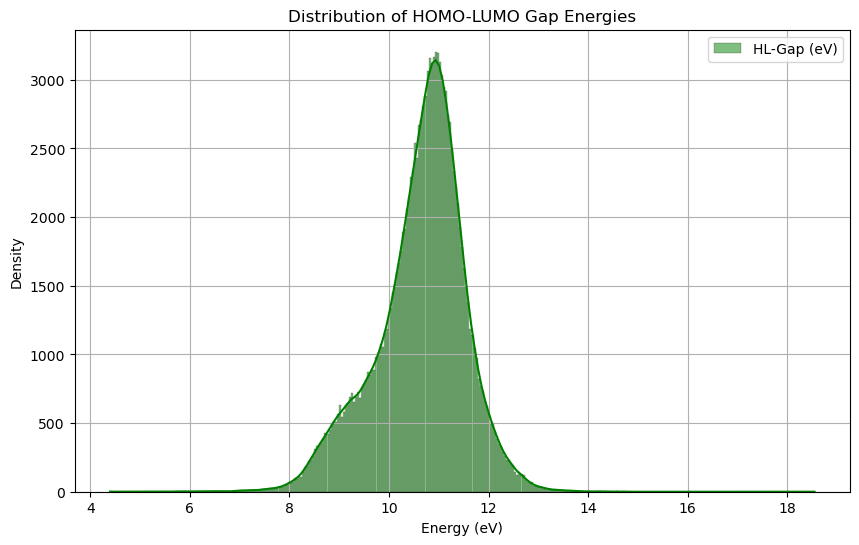

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(df_qm9["GW-GAP"], color="green", label="HL-Gap (eV)", kde=True)
plt.title("Distribution of HOMO-LUMO Gap Energies")
plt.xlabel("Energy (eV)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
df_qm9.dropna(subset=["mol"], inplace=True)
print(f"Removed rows with None in 'mol' column. New shape: {df_qm9.shape}")
print(df_qm9.head())  ## 3. Calculate Descriptors

Removed rows with None in 'mol' column. New shape: (133247, 63)
  mol_id          A           B           C      mu  alpha    homo    lumo  \
0  gdb_1  157.71180  157.709970  157.706990  0.0000  13.21 -0.3877  0.1171   
1  gdb_2  293.60975  293.541110  191.393970  1.6256   9.46 -0.2570  0.0829   
2  gdb_3  799.58812  437.903860  282.945450  1.8511   6.31 -0.2928  0.0687   
3  gdb_4    0.00000   35.610036   35.610036  0.0000  16.28 -0.2845  0.0506   
4  gdb_5    0.00000   44.593883   44.593883  2.8937  12.99 -0.3604  0.0191   

      gap       r2  ...  vir_0_r2  vir_err  vir_r2   vir_scf  vir_scf_err  \
0  0.5048  35.3641  ...       1.0      0.0     1.0  1.010190          0.0   
1  0.3399  26.1563  ...       1.0      0.0     1.0  0.981538          0.0   
2  0.3615  19.0002  ...       1.0      0.0     1.0  1.066235          0.0   
3  0.3351  59.5248  ...       1.0      0.0     1.0  1.062676          0.0   
4  0.3796  48.7476  ...       1.0      0.0     1.0  1.285083          0.0   

   v

In [13]:
pkl_path = Path("../data/processed/calc_descriptors_final.pkl")
try:
    df_descr_template = pd.read_pickle(pkl_path)
    descriptor_names = list(df_descr_template.columns)
    print(f"Loaded {len(descriptor_names)} descriptor names from {pkl_path}")
    # show a short preview
    print(descriptor_names)
except FileNotFoundError:
    descriptor_names = None
    print(
        f"Error: {pkl_path} not found. Make sure you generated it in 'compare_to_datasets.ipynb'."
    )
except Exception as e:
    descriptor_names = None
    print(f"Failed to load descriptors template: {e}")

Loaded 56 descriptor names from ../data/processed/calc_descriptors_final.pkl
['MaxAbsEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'SPS', 'MolWt', 'NumRadicalElectrons', 'AvgIpc', 'BalabanJ', 'HallKierAlpha', 'Ipc', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5', 'PEOE_VSA6', 'PEOE_VSA7', 'SMR_VSA10', 'SMR_VSA3', 'SMR_VSA4', 'SMR_VSA6', 'SMR_VSA7', 'SMR_VSA9', 'SlogP_VSA1', 'SlogP_VSA10', 'SlogP_VSA12', 'SlogP_VSA7', 'SlogP_VSA8', 'EState_VSA11', 'EState_VSA2', 'EState_VSA3', 'EState_VSA4', 'EState_VSA5', 'EState_VSA6', 'VSA_EState10', 'VSA_EState6', 'NumAliphaticHeterocycles', 'NumAromaticCarbocycles', 'NumAromaticHeterocycles', 'MolLogP', 'fr_Al_COO', 'fr_Al_OH_noTert', 'fr_Ar_N', 'fr_NH0', 'fr_NH2', 'fr_allylic_oxid', 'fr_aniline', 'fr_aryl_methyl', 'fr_bicyclic', 'fr_ester', 'fr_ketone', 'fr_para_hydroxylation', 'fr_piperdine']


In [14]:
df_qm9.dropna(subset=["mol"], inplace=True)
df_qm9

,mol_id,A,B,C,mu,alpha,homo,lumo,gap,r2,...,vir_0_r2,vir_err,vir_r2,vir_scf,vir_scf_err,vir_scf_r2,virs,virs_0,virs_scf,GW-GAP
0,gdb_1,157.71180,157.709970,157.706990,0.0000,13.21,-0.3877,0.1171,0.5048,35.3641,...,1.0,0.0,1.0,1.010190,0.0,1.0,1.156,1.156,1.253,15.831127
1,gdb_2,293.60975,293.541110,191.393970,1.6256,9.46,-0.2570,0.0829,0.3399,26.1563,...,1.0,0.0,1.0,0.981538,0.0,1.0,1.117,1.117,1.231,12.486077
2,gdb_3,799.58812,437.903860,282.945450,1.8511,6.31,-0.2928,0.0687,0.3615,19.0002,...,1.0,0.0,1.0,1.066235,0.0,1.0,1.212,1.212,1.326,14.340314
3,gdb_4,0.00000,35.610036,35.610036,0.0000,16.28,-0.2845,0.0506,0.3351,59.5248,...,1.0,0.0,1.0,1.062676,0.0,1.0,3.096,1.118,1.348,12.848649
4,gdb_5,0.00000,44.593883,44.593883,2.8937,12.99,-0.3604,0.0191,0.3796,48.7476,...,1.0,0.0,1.0,1.285083,0.0,1.0,2.900,1.163,1.517,15.416417
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133878,gdb_133879,3.52243,2.185850,1.902520,1.4529,77.63,-0.2229,0.0977,0.3206,796.9713,...,1.0,0.0,1.0,0.874541,0.0,1.0,0.957,0.957,1.089,10.133162
133879,gdb_133880,3.56068,2.195510,1.920670,1.3774,73.24,-0.2427,0.0904,0.3331,777.3913,...,1.0,0.0,1.0,0.893420,0.0,1.0,0.976,0.976,1.109,10.803975
133882,gdb_133883,3.67118,2.143140,1.895010,1.2480,73.60,-0.2233,0.0720,0.2953,780.3553,...,1.0,0.0,1.0,0.883799,0.0,1.0,0.964,0.964,1.120,10.135611
133883,gdb_133884,3.52845,2.151310,1.865820,1.9576,77.40,-0.2122,0.0881,0.3003,803.1904,...,1.0,0.0,1.0,0.870676,0.0,1.0,0.944,0.944,1.087,9.809811


## 4. Prediction

In [15]:
def RDkit_descriptors(smiles_series, descriptor_names=None):
    """
    Calculate RDKit descriptors for a series of SMILES.

    If `descriptor_names` is provided it will be used as the list of
    descriptor names to compute (preserves order). Otherwise the full
    RDKit descriptor list will be used.
    """
    # Determine which descriptor names to compute
    if descriptor_names is None:
        names_to_use = [x[0] for x in descriptor_names]
        print(
            f"No descriptor_names provided — computing full RDKit list ({len(names_to_use)})"
        )
    else:
        names_to_use = list(descriptor_names)
        print(f"Computing {len(names_to_use)} descriptors from provided template")

    # Create the RDKit calculator with the chosen names
    calc = MoleculeDescriptors.MolecularDescriptorCalculator(names_to_use)
    desc_names = calc.GetDescriptorNames()

    Mol_descriptors = []
    for smi in smiles_series:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            try:
                mol_h = Chem.AddHs(mol)
                descriptors = calc.CalcDescriptors(mol_h)
                Mol_descriptors.append(descriptors)
            except Exception:
                # If calculation fails for a molecule, append NaNs
                Mol_descriptors.append([np.nan] * len(desc_names))
        else:
            Mol_descriptors.append([np.nan] * len(desc_names))

    return pd.DataFrame(Mol_descriptors, columns=desc_names)


# Use the extracted descriptor_names if available; otherwise fall back
print("Calculating RDKit descriptors for the QM9 sample (template-aware)...")
try:
    df_qm9_descriptors = RDkit_descriptors(
        df_qm9["smiles"],
        descriptor_names=descriptor_names,
    )
    print("Descriptors calculated.")
    print(df_qm9_descriptors.head())
except NameError as e:
    print("Error: required variables not defined in the notebook kernel —", e)
    raise
except Exception as e:
    print("Descriptor calculation failed:", e)
    raise

Calculating RDKit descriptors for the QM9 sample (template-aware)...
Computing 56 descriptors from provided template
Descriptors calculated.
   MaxAbsEStateIndex  MinAbsEStateIndex  MinEStateIndex  SPS   MolWt  \
0           5.937500           2.500000       -2.500000  777  16.043   
1           5.750000           0.250000       -0.250000  777  17.031   
2           5.375000           2.750000        2.750000  777  18.015   
3           5.902778           1.597222        1.597222  777  26.038   
4           6.986111           1.000000        1.000000  777  27.026   

   NumRadicalElectrons  AvgIpc  BalabanJ  HallKierAlpha       Ipc  ...  \
0                    0     777  3.023716           0.00  3.609640  ...   
1                    0     777  2.323790          -0.04  3.245112  ...   
2                    0     777  1.632993          -0.04  2.754888  ...   
3                    0     777  2.825840          -0.44  6.854753  ...   
4                    0     777  2.475534          -0.51 

In [16]:
df_qm9_descriptors

,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,SPS,MolWt,NumRadicalElectrons,AvgIpc,BalabanJ,HallKierAlpha,Ipc,...,fr_NH0,fr_NH2,fr_allylic_oxid,fr_aniline,fr_aryl_methyl,fr_bicyclic,fr_ester,fr_ketone,fr_para_hydroxylation,fr_piperdine
0,5.937500,2.500000,-2.500000,777,16.043,0,777,3.023716,0.00,3.609640,...,0,0,0,0,0,0,0,0,0,0
1,5.750000,0.250000,-0.250000,777,17.031,0,777,2.323790,-0.04,3.245112,...,0,0,0,0,0,0,0,0,0,0
2,5.375000,2.750000,2.750000,777,18.015,0,777,1.632993,-0.04,2.754888,...,0,0,0,0,0,0,0,0,0,0
3,5.902778,1.597222,1.597222,777,26.038,0,777,2.825840,-0.44,6.854753,...,0,0,0,0,0,0,0,0,0,0
4,6.986111,1.000000,1.000000,777,27.026,0,777,2.475534,-0.51,2.754888,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133242,8.343750,1.357639,-2.625694,777,120.175,0,777,2.017227,-0.04,13977.000752,...,0,0,0,0,0,0,0,0,0,3
133243,8.218750,1.916667,-2.210417,777,120.151,0,777,1.966972,-0.04,6427.238767,...,0,0,0,0,0,0,0,0,0,0
133244,8.315972,1.501597,-2.676042,777,122.171,0,777,2.017227,-0.08,13977.000752,...,0,0,0,0,0,0,0,0,0,3
133245,8.331597,1.485972,-2.613542,777,120.175,0,777,2.017227,-0.04,13977.000752,...,0,0,0,0,0,0,0,0,0,1


In [17]:
df1_reset = df_qm9.reset_index(drop=True)
df2_reset = df_qm9_descriptors.reset_index(drop=True)

# Now concat them. They both have a matching [0, 1, 2...] index.
df_qm9_aug = pd.concat([df1_reset, df2_reset], axis=1)
df_qm9_aug

,mol_id,A,B,C,mu,alpha,homo,lumo,gap,r2,...,fr_NH0,fr_NH2,fr_allylic_oxid,fr_aniline,fr_aryl_methyl,fr_bicyclic,fr_ester,fr_ketone,fr_para_hydroxylation,fr_piperdine
0,gdb_1,157.71180,157.709970,157.706990,0.0000,13.21,-0.3877,0.1171,0.5048,35.3641,...,0,0,0,0,0,0,0,0,0,0
1,gdb_2,293.60975,293.541110,191.393970,1.6256,9.46,-0.2570,0.0829,0.3399,26.1563,...,0,0,0,0,0,0,0,0,0,0
2,gdb_3,799.58812,437.903860,282.945450,1.8511,6.31,-0.2928,0.0687,0.3615,19.0002,...,0,0,0,0,0,0,0,0,0,0
3,gdb_4,0.00000,35.610036,35.610036,0.0000,16.28,-0.2845,0.0506,0.3351,59.5248,...,0,0,0,0,0,0,0,0,0,0
4,gdb_5,0.00000,44.593883,44.593883,2.8937,12.99,-0.3604,0.0191,0.3796,48.7476,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133242,gdb_133879,3.52243,2.185850,1.902520,1.4529,77.63,-0.2229,0.0977,0.3206,796.9713,...,0,0,0,0,0,0,0,0,0,3
133243,gdb_133880,3.56068,2.195510,1.920670,1.3774,73.24,-0.2427,0.0904,0.3331,777.3913,...,0,0,0,0,0,0,0,0,0,0
133244,gdb_133883,3.67118,2.143140,1.895010,1.2480,73.60,-0.2233,0.0720,0.2953,780.3553,...,0,0,0,0,0,0,0,0,0,3
133245,gdb_133884,3.52845,2.151310,1.865820,1.9576,77.40,-0.2122,0.0881,0.3003,803.1904,...,0,0,0,0,0,0,0,0,0,1


In [18]:
df_qm9_aug.columns

Index(['mol_id', 'A', 'B', 'C', 'mu', 'alpha', 'homo', 'lumo', 'gap', 'r2',
       ...
       'fr_NH0', 'fr_NH2', 'fr_allylic_oxid', 'fr_aniline', 'fr_aryl_methyl',
       'fr_bicyclic', 'fr_ester', 'fr_ketone', 'fr_para_hydroxylation',
       'fr_piperdine'],
      dtype='object', length=119)

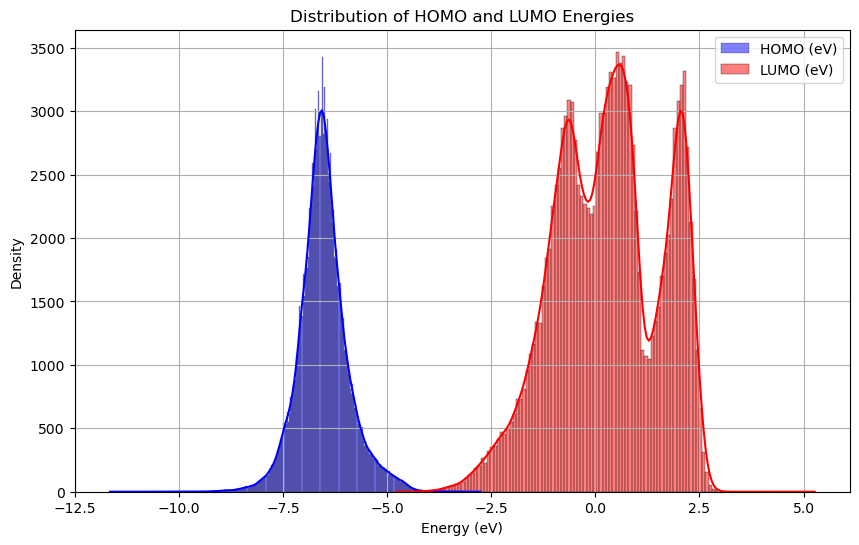

In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(df_qm9["homo_eV"], color="blue", label="HOMO (eV)", kde=True)
sns.histplot(df_qm9["lumo_eV"], color="red", label="LUMO (eV)", kde=True)
plt.title("Distribution of HOMO and LUMO Energies")
plt.xlabel("Energy (eV)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()

## 4. Prediction

In [20]:
X_sample = df_qm9_descriptors.copy()
X_sample.replace([np.inf, -np.inf], np.nan, inplace=True)
X_sample = X_sample.dropna(axis="rows")
zero_cols = X_sample.columns[(X_sample == 0).all()]
# X_sample.drop(labels=zero_cols, axis=1, inplace=True)
print(zero_cols)
# Apply the same scaling used in training
scaler = MinMaxScaler()
# Use .loc to prevent a potential SettingWithCopyWarning
X_sample.loc[:, "Ipc"] = scaler.fit_transform(X_sample["Ipc"].values.reshape(-1, 1))

ss = StandardScaler()
# Fit StandardScaler on training features for consistency
# This will now work because X_sample has no NaNs
X_sample_scaled = ss.fit_transform(X_sample)

print(X_sample_scaled.shape)

X_sample

Index(['SlogP_VSA12', 'EState_VSA11', 'VSA_EState10'], dtype='object')
(133247, 56)


,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,SPS,MolWt,NumRadicalElectrons,AvgIpc,BalabanJ,HallKierAlpha,Ipc,...,fr_NH0,fr_NH2,fr_allylic_oxid,fr_aniline,fr_aryl_methyl,fr_bicyclic,fr_ester,fr_ketone,fr_para_hydroxylation,fr_piperdine
0,5.937500,2.500000,-2.500000,777,16.043,0,777,3.023716,0.00,0.000005,...,0,0,0,0,0,0,0,0,0,0
1,5.750000,0.250000,-0.250000,777,17.031,0,777,2.323790,-0.04,0.000003,...,0,0,0,0,0,0,0,0,0,0
2,5.375000,2.750000,2.750000,777,18.015,0,777,1.632993,-0.04,0.000000,...,0,0,0,0,0,0,0,0,0,0
3,5.902778,1.597222,1.597222,777,26.038,0,777,2.825840,-0.44,0.000023,...,0,0,0,0,0,0,0,0,0,0
4,6.986111,1.000000,1.000000,777,27.026,0,777,2.475534,-0.51,0.000000,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133242,8.343750,1.357639,-2.625694,777,120.175,0,777,2.017227,-0.04,0.079149,...,0,0,0,0,0,0,0,0,0,3
133243,8.218750,1.916667,-2.210417,777,120.151,0,777,1.966972,-0.04,0.036388,...,0,0,0,0,0,0,0,0,0,0
133244,8.315972,1.501597,-2.676042,777,122.171,0,777,2.017227,-0.08,0.079149,...,0,0,0,0,0,0,0,0,0,3
133245,8.331597,1.485972,-2.613542,777,120.175,0,777,2.017227,-0.04,0.079149,...,0,0,0,0,0,0,0,0,0,1


In [21]:
# --- Load the trained model ---
try:
    reg = load("../data/processed/reg_NN_MLP.joblib")
    # reg = load("../data/processed/reg_RF.joblib")
except FileNotFoundError:
    print("Error: '../data/processed/reg_NN_MLP.joblib' not found.")
    exit()

In [22]:
gap_pred = reg.predict(X_sample_scaled)

df_plot = X_sample.copy()
df_plot["MLPR-GAP"] = gap_pred
df_plot["QM9-GAP"] = df_qm9_aug.loc[X_sample.index, "gap_eV"]
df_plot = df_plot.join(df_qm9_aug["GW-GAP"])

print(df_plot.columns)
df_plot

Index(['MaxAbsEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'SPS',
       'MolWt', 'NumRadicalElectrons', 'AvgIpc', 'BalabanJ', 'HallKierAlpha',
       'Ipc', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14',
       'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5', 'PEOE_VSA6',
       'PEOE_VSA7', 'SMR_VSA10', 'SMR_VSA3', 'SMR_VSA4', 'SMR_VSA6',
       'SMR_VSA7', 'SMR_VSA9', 'SlogP_VSA1', 'SlogP_VSA10', 'SlogP_VSA12',
       'SlogP_VSA7', 'SlogP_VSA8', 'EState_VSA11', 'EState_VSA2',
       'EState_VSA3', 'EState_VSA4', 'EState_VSA5', 'EState_VSA6',
       'VSA_EState10', 'VSA_EState6', 'NumAliphaticHeterocycles',
       'NumAromaticCarbocycles', 'NumAromaticHeterocycles', 'MolLogP',
       'fr_Al_COO', 'fr_Al_OH_noTert', 'fr_Ar_N', 'fr_NH0', 'fr_NH2',
       'fr_allylic_oxid', 'fr_aniline', 'fr_aryl_methyl', 'fr_bicyclic',
       'fr_ester', 'fr_ketone', 'fr_para_hydroxylation', 'fr_piperdine',
       'MLPR-GAP', 'QM9-GAP', 'GW-GAP'],
      dtype='object')


,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,SPS,MolWt,NumRadicalElectrons,AvgIpc,BalabanJ,HallKierAlpha,Ipc,...,fr_aniline,fr_aryl_methyl,fr_bicyclic,fr_ester,fr_ketone,fr_para_hydroxylation,fr_piperdine,MLPR-GAP,QM9-GAP,GW-GAP
0,5.937500,2.500000,-2.500000,777,16.043,0,777,3.023716,0.00,0.000005,...,0,0,0,0,0,0,0,1.387613,13.736315,15.831127
1,5.750000,0.250000,-0.250000,777,17.031,0,777,2.323790,-0.04,0.000003,...,0,0,0,0,0,0,0,-0.214807,9.249155,12.486077
2,5.375000,2.750000,2.750000,777,18.015,0,777,1.632993,-0.04,0.000000,...,0,0,0,0,0,0,0,1.070853,9.836921,14.340314
3,5.902778,1.597222,1.597222,777,26.038,0,777,2.825840,-0.44,0.000023,...,0,0,0,0,0,0,0,0.822407,9.118540,12.848649
4,6.986111,1.000000,1.000000,777,27.026,0,777,2.475534,-0.51,0.000000,...,0,0,0,0,0,0,0,1.326421,10.329447,15.416417
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133242,8.343750,1.357639,-2.625694,777,120.175,0,777,2.017227,-0.04,0.079149,...,0,0,0,0,0,0,3,1.298436,8.723975,10.133162
133243,8.218750,1.916667,-2.210417,777,120.151,0,777,1.966972,-0.04,0.036388,...,0,0,0,0,0,0,0,2.838727,9.064117,10.803975
133244,8.315972,1.501597,-2.676042,777,122.171,0,777,2.017227,-0.08,0.079149,...,0,0,0,0,0,0,3,2.405943,8.035526,10.135611
133245,8.331597,1.485972,-2.613542,777,120.175,0,777,2.017227,-0.04,0.079149,...,0,0,0,0,0,0,1,1.993485,8.171583,9.809811


In [ ]:
# --- 2x2 heatmaps: distributions per class (aromatic / aliphatic) ---
from matplotlib.colors import LogNorm

# First create labels based on molecular descriptors
aromatic_cols = ["NumAromaticCarbocycles", "NumAromaticHeterocycles"]
df_plot["label"] = (
    df_plot[aromatic_cols]
    .fillna(0)
    .sum(axis=1)
    .apply(lambda v: "aromatic" if v > 0 else "aliphatic")
)

# Prepare subsets
aromatic_df = df_plot[df_plot["label"] == "aromatic"]
aliphatic_df = df_plot[df_plot["label"] == "aliphatic"]

print("Label counts:")
print(df_plot["label"].value_counts())
print(f"\nCounts: aromatic={len(aromatic_df)}, aliphatic={len(aliphatic_df)}")

# Prepare the four (x,y) pairs:
# (QM9-GAP, MLPR-GAP) and (GW-GAP, MLPR-GAP) for each class
pairs = [
    (aromatic_df["QM9-GAP"].to_numpy(), aromatic_df["MLPR-GAP"].to_numpy()),
    (aromatic_df["GW-GAP"].to_numpy(), aromatic_df["MLPR-GAP"].to_numpy()),
    (aliphatic_df["QM9-GAP"].to_numpy(), aliphatic_df["MLPR-GAP"].to_numpy()),
    (aliphatic_df["GW-GAP"].to_numpy(), aliphatic_df["MLPR-GAP"].to_numpy()),
]

# Compute histograms with same bins and ranges for comparability
bins = 200
ranges = [
    [[0, 13], [0, 13]],  # QM9 vs MLPR
    [[0, 13], [0, 13]],  # GW vs MLPR (keep same x-range)
]

heatmaps = []
edges_x = []
edges_y = []
for x, y in pairs:
    # Guard against empty arrays
    if x.size == 0 or y.size == 0:
        hm = np.zeros((bins, bins))
        xe = np.linspace(0, 13, bins + 1)
        ye = np.linspace(0, 13, bins + 1)
    else:
        hm, xe, ye = np.histogram2d(
            x, y, bins=bins, range=[[0, 13], [0, 13]], density=False
        )
    heatmaps.append(hm)
    edges_x.append(xe)
    edges_y.append(ye)

# Determine shared color scale (avoid zeros for LogNorm)
pos_vals = np.concatenate(
    [hm[hm > 0].flatten() if (hm > 0).any() else np.array([1]) for hm in heatmaps]
)
vmin = max(float(pos_vals.min()), 1.0)
vmax = float(max(hm.max() for hm in heatmaps))

# Plot 2x2 grid
plt.clf()
fig, axs = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
labels = [
    "Aromatic: QM9-DFT vs MLPR",
    "Aromatic: GW (QP) vs MLPR",
    "Aliphatic: QM9-DFT vs MLPR",
    "Aliphatic: GW (QP) vs MLPR",
]

for idx, ax in enumerate(axs.flatten()):
    hm = heatmaps[idx]
    xe = edges_x[idx]
    ye = edges_y[idx]
    im = ax.imshow(
        hm.T,
        extent=[xe[0], xe[-1], ye[0], ye[-1]],
        origin="lower",
        cmap="viridis",
        aspect="auto",
        norm=LogNorm(vmin=vmin, vmax=vmax),
    )
    ax.set_xlim(0, 13)
    ax.set_ylim(0, 13)
    ax.grid(True)
    ax.tick_params(axis="both", which="major", labelsize=10)
    ax.set_xlabel("Gap [eV]", fontsize=12)
    ax.set_ylabel("MLPR GAP [eV]", fontsize=12)
    ax.set_title(labels[idx], fontsize=14)
    ax.plot([0, 13], [0, 13], "k--", linewidth=0.8)

# single colorbar for all
cbar = fig.colorbar(im, ax=axs, orientation="vertical", shrink=0.8, pad=0.02)
cbar.set_label("Number of molecules", fontsize=12)
cbar.ax.tick_params(labelsize=10)

out_dir = Path("./")
fig_path = out_dir / "xtb_modl_qm9_gw_aromatic_aliphatic_2x2.png"
plt.savefig(fig_path, dpi=600)
print(f"\nSaved 2x2 heatmap to {fig_path}")
plt.show()

Label counts:
label
aliphatic    111266
aromatic      21981
Name: count, dtype: int64

Counts: aromatic=21981, aliphatic=111266


In [26]:
# Calculate overall mean residuals
mean_residual_mlpr_dft = (df_plot["QM9-GAP"] - df_plot["MLPR-GAP"]).mean()
mean_residual_mlpr_qp = (df_plot["GW-GAP"] - df_plot["MLPR-GAP"]).mean()

print(f"Mean Residual (MLPR vs DFT Gap): {mean_residual_mlpr_dft:.4f} eV")
print(f"Mean Residual (MLPR vs QP Gap): {mean_residual_mlpr_qp:.4f} eV")

# Calculate distribution centers for aromatic and aliphatic sets
print("\nDistribution Centers and Distances:")
print("-" * 50)

# For QM9-DFT Gap
dft_aromatic_center = aromatic_df["QM9-GAP"].mean()
dft_aliphatic_center = aliphatic_df["QM9-GAP"].mean()
dft_center_distance = abs(dft_aromatic_center - dft_aliphatic_center)

print(f"QM9-DFT Gap Centers:")
print(f"  Aromatic:  {dft_aromatic_center:.4f} eV")
print(f"  Aliphatic: {dft_aliphatic_center:.4f} eV")
print(f"  Distance:  {dft_center_distance:.4f} eV")

# For GW Gap
gw_aromatic_center = aromatic_df["GW-GAP"].mean()
gw_aliphatic_center = aliphatic_df["GW-GAP"].mean()
gw_center_distance = abs(gw_aromatic_center - gw_aliphatic_center)

print(f"\nGW Gap Centers:")
print(f"  Aromatic:  {gw_aromatic_center:.4f} eV")
print(f"  Aliphatic: {gw_aliphatic_center:.4f} eV")
print(f"  Distance:  {gw_center_distance:.4f} eV")

# Calculate standard deviations for context
print("\nStandard Deviations:")
print(f"QM9-DFT Gap:")
print(f"  Aromatic:  {aromatic_df['QM9-GAP'].std():.4f} eV")
print(f"  Aliphatic: {aliphatic_df['QM9-GAP'].std():.4f} eV")
print(f"GW Gap:")
print(f"  Aromatic:  {aromatic_df['GW-GAP'].std():.4f} eV")
print(f"  Aliphatic: {aliphatic_df['GW-GAP'].std():.4f} eV")

Mean Residual (MLPR vs DFT Gap): 3.9473 eV
Mean Residual (MLPR vs QP Gap): 7.7523 eV

Distribution Centers and Distances:
--------------------------------------------------
QM9-DFT Gap Centers:
  Aromatic:  5.7119 eV
  Aliphatic: 7.0514 eV
  Distance:  1.3395 eV

GW Gap Centers:
  Aromatic:  9.6344 eV
  Aliphatic: 10.8332 eV
  Distance:  1.1988 eV

Standard Deviations:
QM9-DFT Gap:
  Aromatic:  0.8069 eV
  Aliphatic: 1.2564 eV
GW Gap:
  Aromatic:  0.8809 eV
  Aliphatic: 0.7592 eV
